# EDA - Extended Yale B (Many Images, Few People)

Notebook nay dung de xem nhanh dataset Extended Yale B theo preset nhieu anh, it nguoi; kiem tra threshold, split va hien thi anh mau.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

ROOT

WindowsPath('d:/HCMUTE_project/Math_for_ML/math_for_ml')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from src.process import analyze_subject_count_thresholds, process_extended_yale_b_dataset
from src.utils import plot_sample_images

In [3]:
config = {
    "dataset_name": "extended_yale_b",
    "role": "many_images_few_people",
    "test_size": 0.2,
    "random_state": 42,
    "sample_grid_count": 15,
    "thresholds": [10, 20, 30, 40, 50, 59, 64],
}

config

{'dataset_name': 'extended_yale_b',
 'role': 'many_images_few_people',
 'test_size': 0.2,
 'random_state': 42,
 'sample_grid_count': 15,
 'thresholds': [10, 20, 30, 40, 50, 59, 64]}

## Threshold overview

In [4]:
threshold_df = pd.DataFrame(
    analyze_subject_count_thresholds(
        config["dataset_name"],
        thresholds=config["thresholds"],
        include_ambient=False,
    )
)
display(threshold_df)

,dataset_name,raw_dir,threshold,subjects_kept,samples_kept_without_cap,samples_kept_if_balanced,max_images_available
0,extended_yale_b,D:\HCMUTE_project\Math_for_ML\math_for_ml\data...,10,38,2414,380,64
1,extended_yale_b,D:\HCMUTE_project\Math_for_ML\math_for_ml\data...,20,38,2414,760,64
2,extended_yale_b,D:\HCMUTE_project\Math_for_ML\math_for_ml\data...,30,38,2414,1140,64
3,extended_yale_b,D:\HCMUTE_project\Math_for_ML\math_for_ml\data...,40,38,2414,1520,64
4,extended_yale_b,D:\HCMUTE_project\Math_for_ML\math_for_ml\data...,50,38,2414,1900,64
5,extended_yale_b,D:\HCMUTE_project\Math_for_ML\math_for_ml\data...,59,38,2414,2242,64
6,extended_yale_b,D:\HCMUTE_project\Math_for_ML\math_for_ml\data...,64,31,1984,1984,64


## Process dataset va luu artifact da tach train/test

In [5]:
processed = process_extended_yale_b_dataset(
    flatten=False,
    test_size=config["test_size"],
    random_state=config["random_state"],
    save_artifacts=True,
)

summary = processed["summary"]
display(pd.Series({
    "dataset_name": summary["dataset_name"],
    "role": config["role"],
    "samples_total": summary["samples_total"],
    "classes_total": summary["classes_total"],
    "train_shape": summary["train_shape"],
    "test_shape": summary["test_shape"],
    "stratify_used": summary["stratify_used"],
    "processed_dir": processed["output_dir"],
}))

dataset_name                                       extended_yale_b
role                                        many_images_few_people
samples_total                                                 1180
classes_total                                                   20
train_shape                                         [944, 112, 92]
test_shape                                          [236, 112, 92]
stratify_used                                                 True
processed_dir    D:\HCMUTE_project\Math_for_ML\math_for_ml\data...
dtype: object

In [6]:
subject_counts = pd.Series(processed["metadata"]["subject_names"], name="subject_name").value_counts().sort_values(ascending=False)
subject_count_hist = subject_counts.value_counts().sort_index().rename_axis("images_per_subject").reset_index(name="num_subjects")

display(subject_counts.describe())
display(subject_counts.head(20).rename("images"))
display(subject_count_hist)

count    20.0
mean     59.0
std       0.0
min      59.0
25%      59.0
50%      59.0
75%      59.0
max      59.0
Name: count, dtype: float64

subject_name
yaleB01    59
yaleB02    59
yaleB03    59
yaleB04    59
yaleB05    59
yaleB06    59
yaleB07    59
yaleB08    59
yaleB09    59
yaleB10    59
yaleB19    59
yaleB20    59
yaleB21    59
yaleB22    59
yaleB23    59
yaleB24    59
yaleB25    59
yaleB26    59
yaleB27    59
yaleB28    59
Name: images, dtype: int64

,images_per_subject,num_subjects
0,59,20


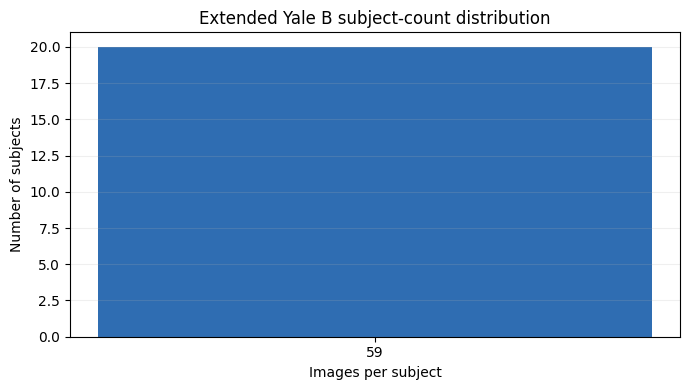

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(subject_count_hist["images_per_subject"].astype(str), subject_count_hist["num_subjects"], color="#2f6db2")
ax.set_xlabel("Images per subject")
ax.set_ylabel("Number of subjects")
ax.set_title("Extended Yale B subject-count distribution")
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()

,count,count
yaleB01,48,11
yaleB02,48,11
yaleB03,47,12
yaleB04,47,12
yaleB05,47,12
yaleB06,47,12
yaleB07,47,12
yaleB08,47,12
yaleB09,47,12
yaleB10,47,12


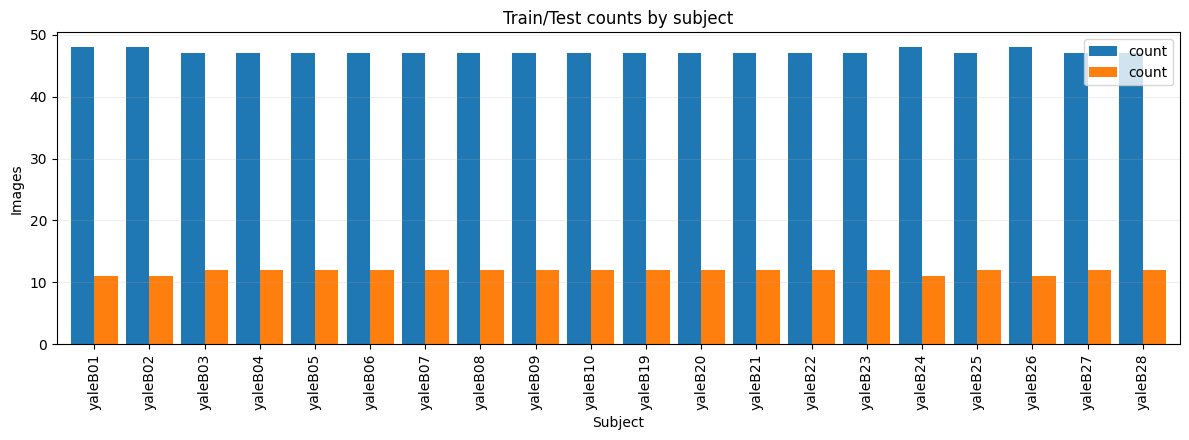

In [8]:
train_counts = pd.Series(processed["train_metadata"]["subject_names"], name="train").value_counts().sort_index()
test_counts = pd.Series(processed["test_metadata"]["subject_names"], name="test").value_counts().sort_index()
split_counts = pd.concat([train_counts, test_counts], axis=1).fillna(0).astype(int)

display(split_counts)

fig, ax = plt.subplots(figsize=(12, 4.5))
split_counts.plot(kind="bar", ax=ax, width=0.85)
ax.set_xlabel("Subject")
ax.set_ylabel("Images")
ax.set_title("Train/Test counts by subject")
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()

## Hien thi anh

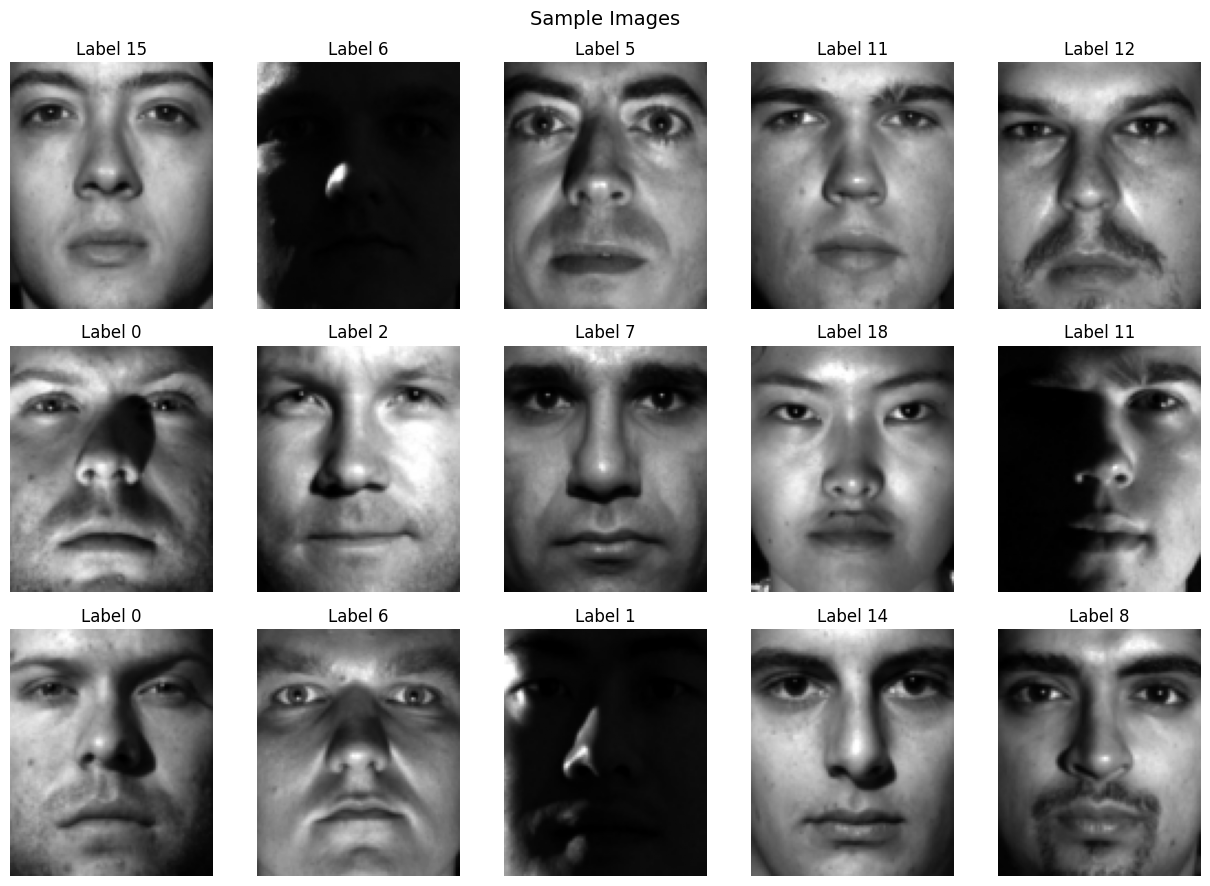

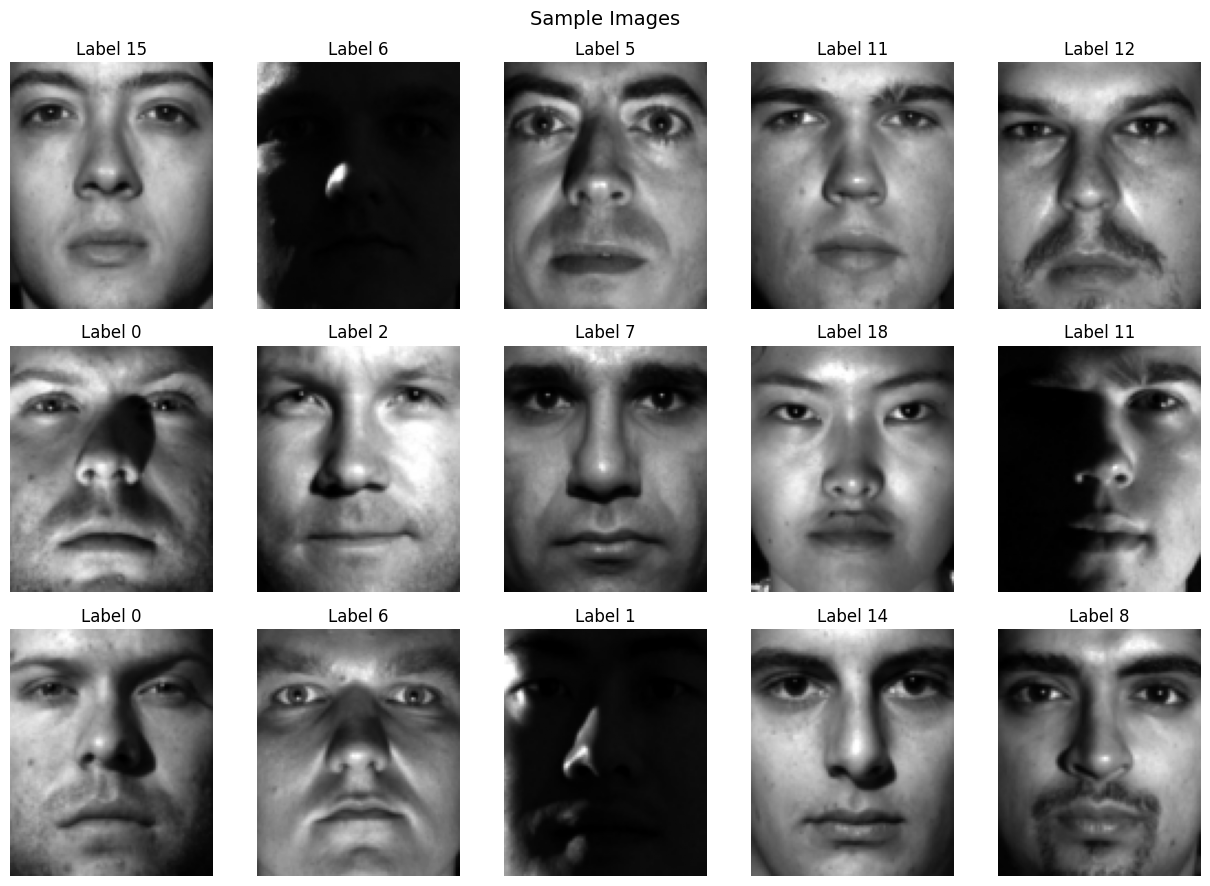

In [9]:
plot_sample_images(
    processed["X_train"],
    labels=processed["y_train"],
    n_samples=config["sample_grid_count"],
)

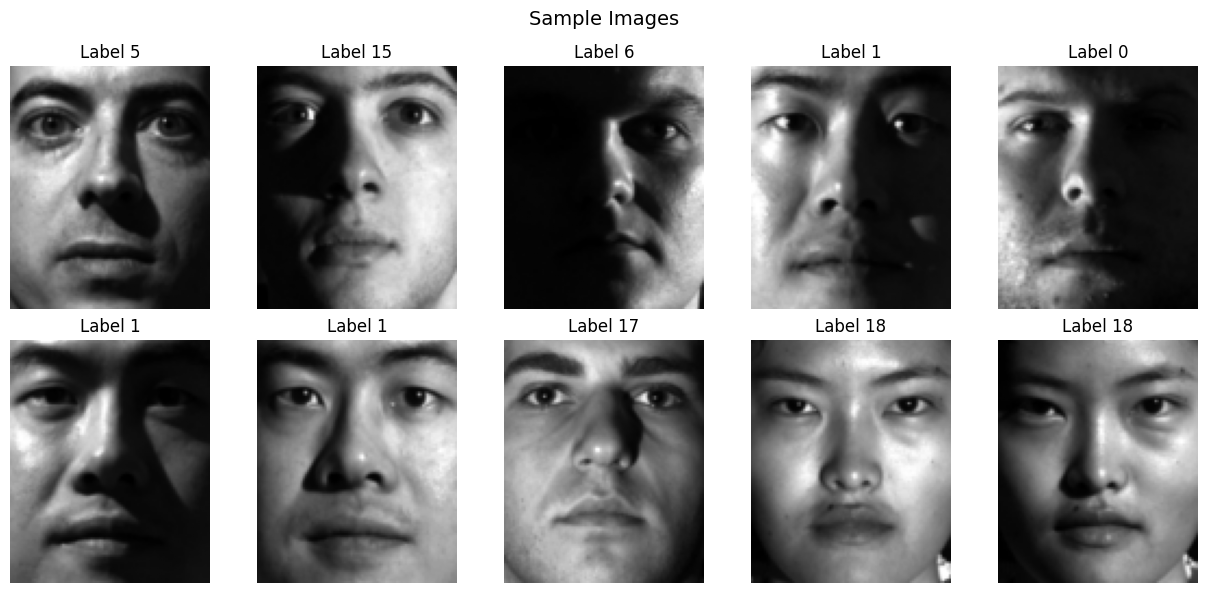

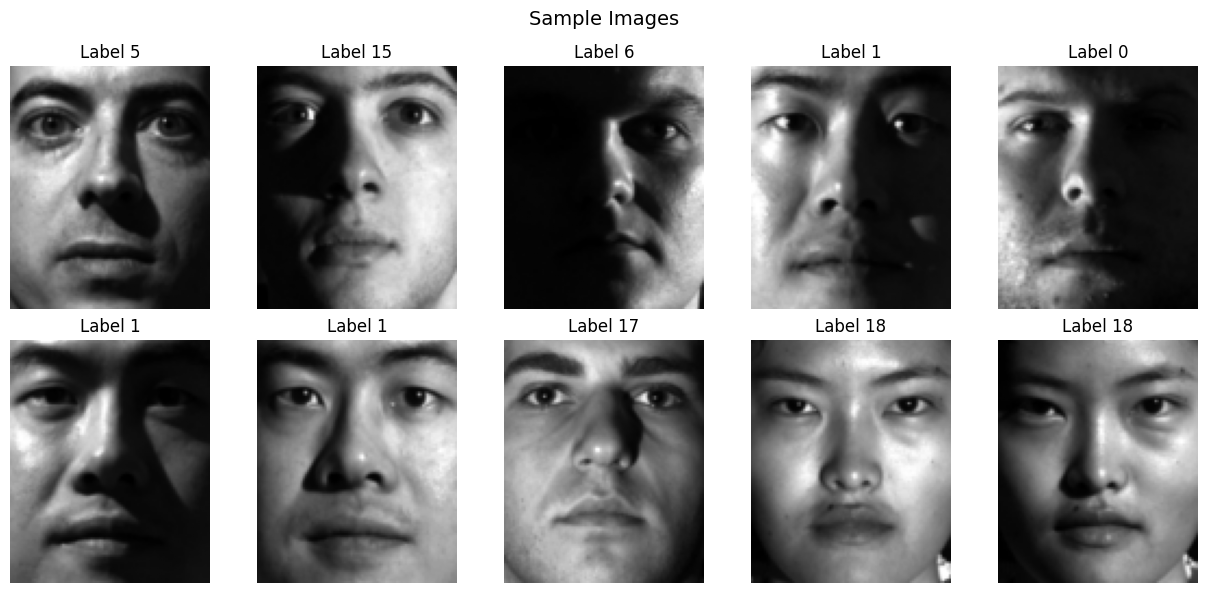

In [10]:
plot_sample_images(
    processed["X_test"],
    labels=processed["y_test"],
    n_samples=min(10, processed["X_test"].shape[0]),
)

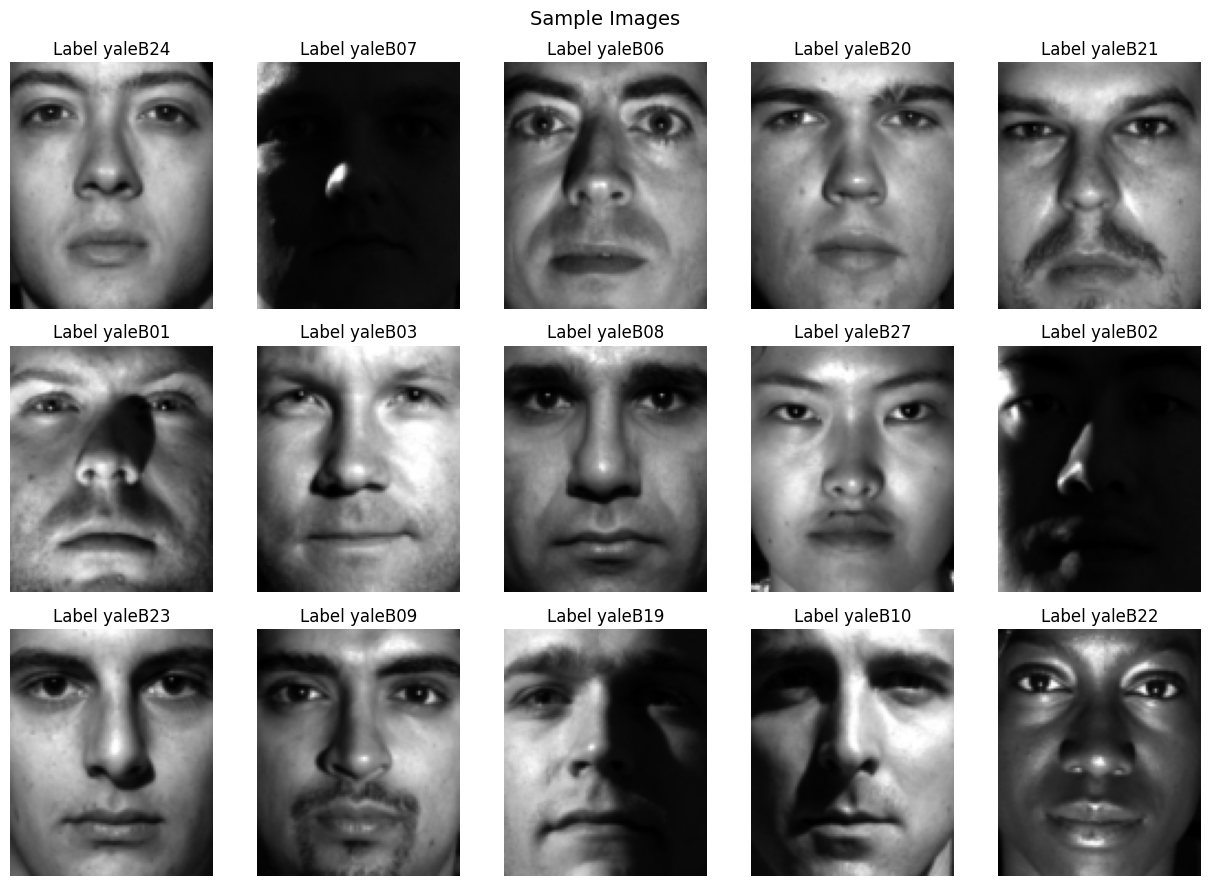

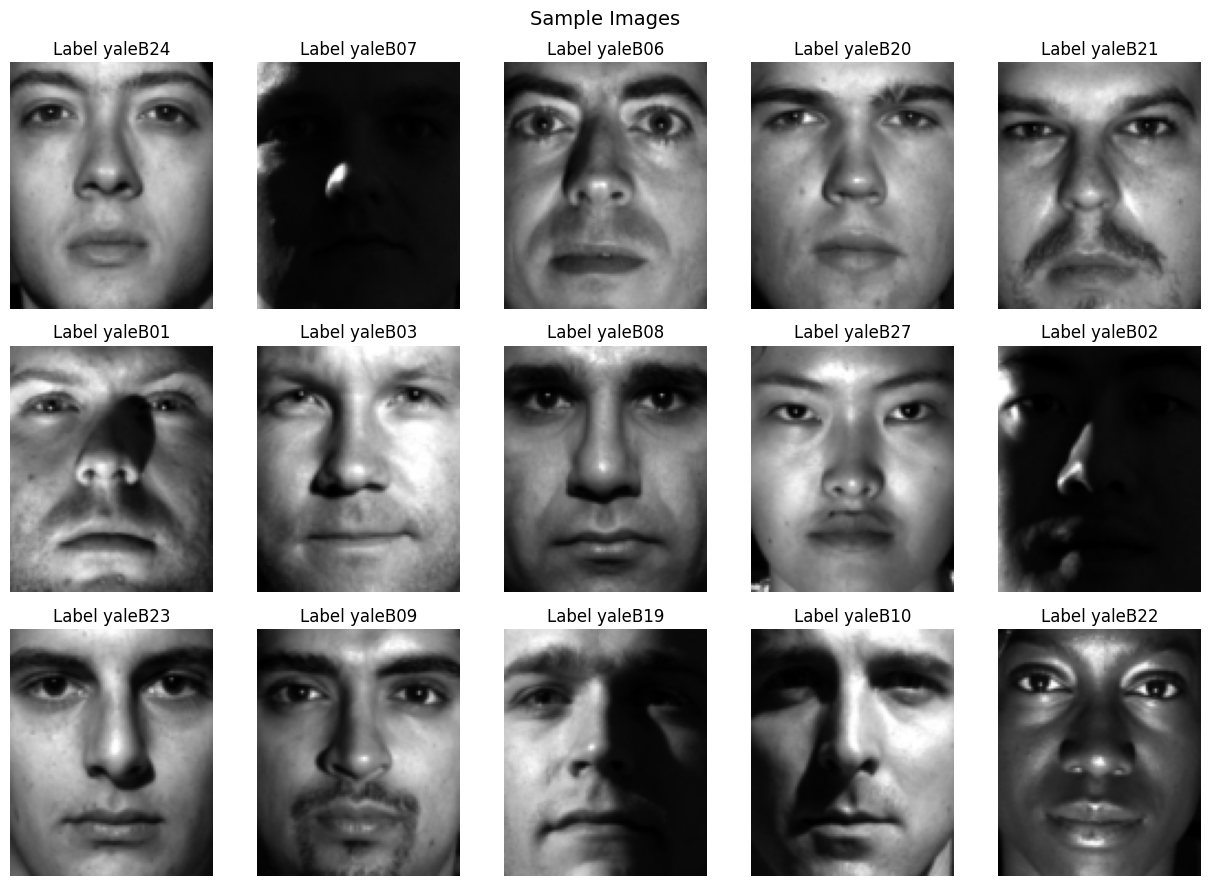

In [11]:
train_subject_names = processed["train_metadata"]["subject_names"]
representative_indices = []
seen_subjects = set()
for index, subject_name in enumerate(train_subject_names):
    if subject_name in seen_subjects:
        continue
    seen_subjects.add(subject_name)
    representative_indices.append(index)
    if len(representative_indices) >= config["sample_grid_count"]:
        break

representative_labels = np.asarray([train_subject_names[index] for index in representative_indices], dtype=object)
plot_sample_images(
    processed["X_train"][representative_indices],
    labels=representative_labels,
    n_samples=len(representative_indices),
)